In [20]:
import os
#os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

os.environ['TF_USE_LEGACY_KERAS'] = '1';

In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
import datetime
import json

In [22]:
!rm -rf fcnn_emotion4
!git clone https://github.com/trucomanx/fcnn_emotion4.git

Cloning into 'fcnn_emotion4'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (187/187), done.
remote: Total 264 (delta 151), reused 173 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (264/264), 2.47 MiB | 25.08 MiB/s, done.
Resolving deltas: 100% (151/151), done.


In [23]:
import sys
sys.path.append('fcnn_emotion4/library');

In [24]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [25]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Variable globales

In [26]:
## Seed for the random variables
seed_number=0;

## Dataset
dataset_base_dir    = "SKELETON";
dataset_labels_file = "train_refface.csv";

dataset_base_test_dir    = "SKELETON";
dataset_labels_test_file = "test_refface.csv";

dataset_name        = "ber2024-skel";

## Training hyperparameters
EPOCAS     = 10000;
BATCH_SIZE = 2048;


## Output
output_base_dir = "/content/drive/My Drive/output_v2";

patience=2000;
NCOD=65;# 57, 61
ANGLE=60;

# Parametros de entrada

In [27]:
for n in range(len(sys.argv)):
    if sys.argv[n]=='--dataset-train-dir':
        dataset_base_dir=sys.argv[n+1];
    elif sys.argv[n]=='--dataset-train-file':
        dataset_labels_file=sys.argv[n+1];
    elif sys.argv[n]=='--dataset-test-dir':
        dataset_base_test_dir=sys.argv[n+1];
    elif sys.argv[n]=='--dataset-test-file':
        dataset_labels_test_file=sys.argv[n+1];
    elif sys.argv[n]=='--dataset-name':
        dataset_name=sys.argv[n+1];
    elif sys.argv[n]=='--epochs':
        EPOCAS=int(sys.argv[n+1]);
    elif sys.argv[n]=='--batch-size':
        BATCH_SIZE=int(sys.argv[n+1]);
    elif sys.argv[n]=='--ncod':
        NCOD=int(sys.argv[n+1]);
    elif sys.argv[n]=='--patience':
        patience=int(sys.argv[n+1]);
    elif sys.argv[n]=='--seed':
        seed_number=int(sys.argv[n+1]);
    elif sys.argv[n]=='--output-dir':
        output_base_dir=sys.argv[n+1];

print('        dataset_base_dir:',dataset_base_dir)
print('     dataset_labels_file:',dataset_labels_file)
print('   dataset_base_test_dir:',dataset_base_test_dir)
print('dataset_labels_test_file:',dataset_labels_test_file)
print('            dataset_name:',dataset_name)
print('                  EPOCAS:',EPOCAS)
print('              BATCH_SIZE:',BATCH_SIZE)
print('                    NCOD:',NCOD)
print('                patience:',patience)
print('             seed_number:',seed_number)
print('         output_base_dir:',output_base_dir)

        dataset_base_dir: SKELETON
     dataset_labels_file: train_refface.csv
   dataset_base_test_dir: SKELETON
dataset_labels_test_file: test_refface.csv
            dataset_name: ber2024-skel
                  EPOCAS: 10000
              BATCH_SIZE: 2048
                    NCOD: 65
                patience: 2000
             seed_number: 0
         output_base_dir: /content/drive/My Drive/output_v2


# Set seed of random variables


In [28]:
np.random.seed(seed_number)
tf.keras.utils.set_random_seed(seed_number);

# Loading data of dataset

In [29]:
# Load filenames and labels
train_val_df = pd.read_csv(os.path.join(dataset_base_dir,dataset_labels_file));
#print(train_val_df)

# Setting labels
Y = train_val_df[['label']];
L=np.shape(Y)[0];

# Load test filenames and labels
test_df = pd.read_csv(os.path.join(dataset_base_test_dir,dataset_labels_test_file));

print('\n\ntest_df')
print(test_df)




test_df
               d0          d1        d2          d3          d4        d5  \
0      537.976257  238.525681  0.983632  565.955750  210.160065  0.982727   
1      758.699402  230.059570  0.992689  789.930725  199.719833  0.992270   
2      681.868408  178.990601  0.994408  709.298889  161.415405  0.992185   
3      772.282715  314.533051  0.983139  788.367310  283.748871  0.983954   
4      584.621216  293.508545  0.991155  615.000977  267.278564  0.992229   
...           ...         ...       ...         ...         ...       ...   
16659  906.220459  144.029602  0.986144  925.095642  130.282806  0.982834   
16660  753.422363  154.049149  0.991505  779.698975  139.303757  0.989969   
16661  411.412170  124.635284  0.991510  438.397125  110.762329  0.998336   
16662  454.097992  151.338104  0.991810  483.897949  137.739975  0.998655   
16663  394.862885  167.965942  0.992310  430.663452  150.411713  0.998407   

               d6          d7        d8          d9  ...  d42  d4

# Setting the cross-validation split


In [30]:
from sklearn.model_selection import train_test_split

training_df, validation_df = train_test_split(train_val_df, test_size=0.2,shuffle=True, stratify=Y)

print('\n\ntraining_df')
print(training_df);


print('\n\nvalidation_df')
print(validation_df)



training_df
               d0          d1        d2          d3          d4        d5  \
19428  806.611938  260.589508  0.992949  826.931824  238.117630  0.989533   
9869   669.062195  283.694855  0.993476  686.606079  251.548187  0.992493   
22859  876.011230  147.786530  0.994281  899.385132  132.164764  0.990409   
21535  901.783386  122.958977  0.989146  907.286133  109.813828  0.980790   
17711  389.154510  245.355972  0.997699  414.687134  222.612000  0.990036   
...           ...         ...       ...         ...         ...       ...   
18318  822.085632  265.952606  0.991174  840.199158  237.636292  0.991836   
6689   596.559143  188.844696  0.993069  621.629578  168.410797  0.994079   
25006  406.708069  223.785782  0.993218  437.620422  200.616211  0.991312   
21126  675.132385  245.845917  0.994344  707.091980  223.280975  0.998485   
17913  695.444214  231.210831  0.986773  722.771423  196.538727  0.991822   

               d6          d7        d8          d9  ...  d42

# Creating output directory

In [31]:
output_dir = os.path.join(output_base_dir,dataset_name,'training_validation_holdout','onlycls_ncod'+str(NCOD));

os.makedirs(output_base_dir,exist_ok = True);

os.makedirs(output_dir,exist_ok = True);

# Data augmentation configuration

In [32]:
import SkeletonEmotion4Lib.DataAugmentation as sda
import SkeletonEmotion4Lib.lib_tools as slt

training_data_array   = slt.batch_normalize_coordinates(training_df.iloc[:,0:51].values)
validation_data_array = slt.batch_normalize_coordinates(validation_df.iloc[:,0:51].values)
test_data_array       = slt.batch_normalize_coordinates(test_df.iloc[:,0:51].values)


training_dataset = sda.DataAugmentationClsGenerator(training_data_array,
                                                    training_df.iloc[:,51].values,
                                                    batch_size=BATCH_SIZE,
                                                    augment_fn=lambda X: slt.batch_random_rotate_coordinates(X,angle=ANGLE),
                                                    shuffle=True);

validation_dataset = sda.DataAugmentationClsGenerator(  validation_data_array,
                                                        validation_df.iloc[:,51].values,
                                                        batch_size=BATCH_SIZE,
                                                        augment_fn=None,
                                                        shuffle=True);

test_dataset = sda.DataAugmentationClsGenerator(test_data_array,
                                                test_df.iloc[:,51].values,
                                                batch_size=BATCH_SIZE,
                                                augment_fn=None,
                                                shuffle=False);

print('train:',training_data_array.shape)
print('val:',validation_data_array.shape)
print('test:',test_data_array.shape)

train: (21562, 51)
val: (5391, 51)
test: (16664, 51)


# Create new model

In [33]:
import SkeletonEmotion4Lib.lib_model as mpp

model = mpp.create_model_onlycls(load_weights=False,
                                file_of_weight='',
                                ncod=NCOD);

print('input_shape',model.input_shape)
print('output_shape',model.output_shape)
print('')

model.summary()

mpp.save_model_parameters(model, os.path.join(output_dir,'parameters_stats.m'));

input_shape (None, 51)
output_shape (None, 4)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 4)                 80528     
                                                                 
Total params: 80528 (314.56 KB)
Trainable params: 80528 (314.56 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
# COMPILE NEW MODEL
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['categorical_accuracy'])

# CREATE CALLBACKS
best_model_file=os.path.join(output_dir,'model_onlycls_ncod'+str(NCOD)+'.h5');
checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=best_model_file,
                                                save_weights_only=True,
                                                monitor='val_loss',
                                                save_best_only=True,
                                                verbose=1);

# Definindo o callback EarlyStopping
early_stopping = tf.keras.callbacks.EarlyStopping(  monitor='val_loss',
                                                    patience=patience,
                                                    verbose=1,
                                                    restore_best_weights=False);

log_dir = os.path.join(output_dir,"logs","fit",'onlycls-'+datetime.datetime.now().strftime("%Y%m%d-%H%M%S"));
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [35]:
# FIT THE MODEL
history = model.fit(training_dataset,
                    epochs=EPOCAS,
                    validation_data=validation_dataset,
                    callbacks=[checkpoint,early_stopping,tensorboard_callback],
                    verbose=1
                   );

A saída de streaming foi truncada nas últimas 5000 linhas.
11/11 [==============================] - ETA: 0s - loss: 0.4257 - categorical_accuracy: 0.8256
Epoch 1045: val_loss did not improve from 0.83156
11/11 [==============================] - 1s 91ms/step - loss: 0.4257 - categorical_accuracy: 0.8256 - val_loss: 1.1022 - val_categorical_accuracy: 0.6687
Epoch 1046/10000
11/11 [==============================] - ETA: 0s - loss: 0.4253 - categorical_accuracy: 0.8262
Epoch 1046: val_loss did not improve from 0.83156
11/11 [==============================] - 1s 90ms/step - loss: 0.4253 - categorical_accuracy: 0.8262 - val_loss: 1.0871 - val_categorical_accuracy: 0.6748
Epoch 1047/10000
11/11 [==============================] - ETA: 0s - loss: 0.4168 - categorical_accuracy: 0.8324
Epoch 1047: val_loss did not improve from 0.83156
11/11 [==============================] - 1s 94ms/step - loss: 0.4168 - categorical_accuracy: 0.8324 - val_loss: 1.0845 - val_categorical_accuracy: 0.6767
Epoch 1048

max_val_acc 0.6913374066352844


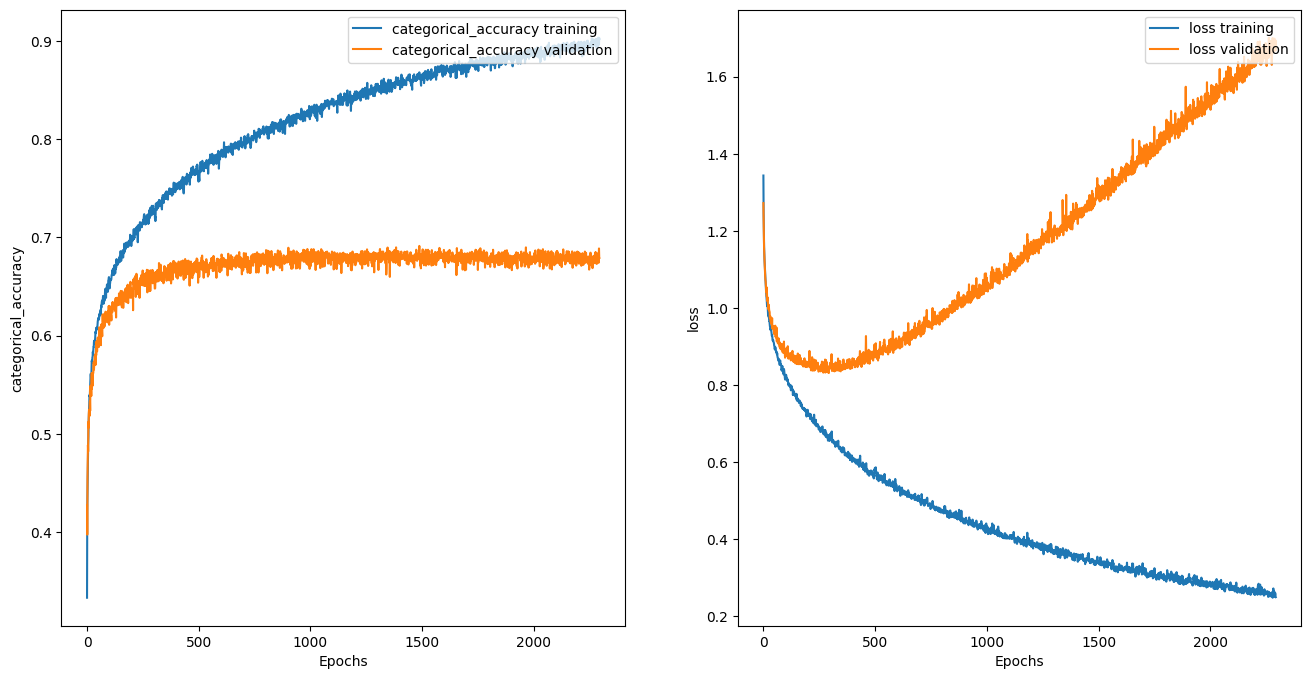

In [36]:
mpp.save_model_history(history,
                       os.path.join(output_dir,"historical.csv"),
                       show=False,
                       labels=['categorical_accuracy','loss']);

In [37]:
# LOAD BEST MODEL to evaluate the performance of the model
model.load_weights(best_model_file);
data_results=dict();

# Evaluate training
results = model.evaluate(training_dataset)
results = dict(zip(model.metrics_names,results))
print('training',results,"\n\n");
for key,value in results.items():
    data_results['train_'+key]=value;

# Evaluate validation
results = model.evaluate(validation_dataset)
results = dict(zip(model.metrics_names,results))
print('validation',results,"\n\n");
for key,value in results.items():
    data_results['val_'+key]=value;

# Evaluate testing
results = model.evaluate(test_dataset)
results = dict(zip(model.metrics_names,results))
print('testing',results,"\n\n");
for key,value in results.items():
    data_results['test_'+key]=value;

data_results['number_of_parameters']=mpp.get_model_parameters(model);
data_results['ncod']=NCOD;
data_results['epochs']=EPOCAS;
data_results['patience']=patience;
data_results['seed']=seed_number;

# final all json
with open(os.path.join(output_dir,"training_data_results.json"), 'w') as f:
    json.dump(data_results, f,indent=4);

tf.keras.backend.clear_session()

11/11 [==============================] - 1s 58ms/step - loss: 0.6513 - categorical_accuracy: 0.7379
training {'loss': 0.6513397097587585, 'categorical_accuracy': 0.7378721833229065} 


3/3 [==============================] - 0s 5ms/step - loss: 0.8316 - categorical_accuracy: 0.6669
validation {'loss': 0.8315566182136536, 'categorical_accuracy': 0.6668521761894226} 


9/9 [==============================] - 0s 3ms/step - loss: 0.8341 - categorical_accuracy: 0.6645
testing {'loss': 0.8341097831726074, 'categorical_accuracy': 0.6645463109016418} 




9/9 [==============================] - 0s 2ms/step
Categorical accuracy: 0.664546327412386
{
    "negative": {
        "precision": 0.60162224797219,
        "recall": 0.6169201520912547,
        "f1-score": 0.6091751730611287,
        "support": 4208.0
    },
    "neutral": {
        "precision": 0.6098675194152581,
        "recall": 0.6035262206148282,
        "f1-score": 0.6066802999318337,
        "support": 4424.0
    },
    "pain": {
        "precision": 0.827431289640592,
        "recall": 0.8075831828733557,
        "f1-score": 0.8173867641300091,
        "support": 3877.0
    },
    "positive": {
        "precision": 0.6393599235729639,
        "recall": 0.6442839951865222,
        "f1-score": 0.6418125149844162,
        "support": 4155.0
    },
    "accuracy": 0.664546327412386,
    "macro avg": {
        "precision": 0.669570245150251,
        "recall": 0.6680783876914902,
        "f1-score": 0.6687636880268469,
        "support": 16664.0
    },
    "weighted avg": {
       

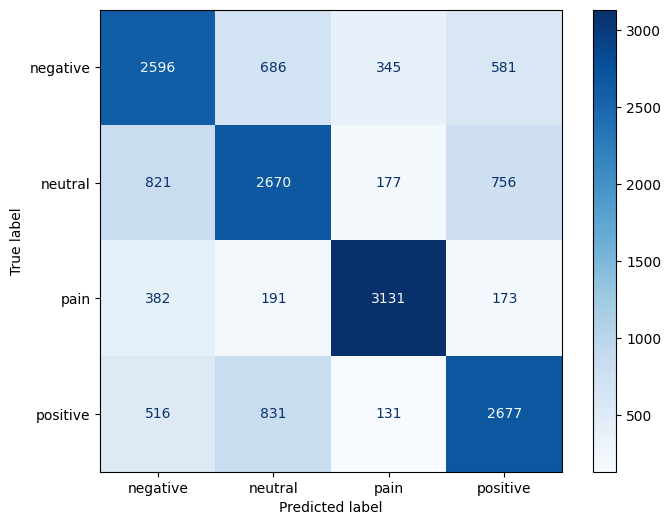

In [38]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

target_names = ['negative','neutral','pain','positive'];

# Predict
Y_pred = model.predict(test_dataset,verbose=1);
y_pred = np.argmax(Y_pred, axis=1);

# Calculate accuracy
categorical_accuracy = np.mean(test_dataset.classes == y_pred);
print(f'Categorical accuracy: {categorical_accuracy}');

# Confusion matrix
CM=confusion_matrix(test_dataset.classes, y_pred);

fname=os.path.join(output_dir,"confusion_matrix.eps");
fig, ax = plt.subplots(figsize=(8,6), dpi=100)
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=target_names)
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.savefig(fname)

cm_dict=dict();
cm_dict['matrix']=CM.tolist();
cm_dict['label']=target_names;
# final all json
with open(os.path.join(output_dir,"confusion_matrix.json"), 'w') as f:
    json.dump(cm_dict, f,indent=4);
    f.close()

# Classification report
fname=os.path.join(output_dir,"classification_report.json")
dict_dat=classification_report(test_dataset.classes, y_pred, target_names=target_names,output_dict=True);
print(json.dumps(dict_dat, indent=4))
with open(fname, 'w') as f:
    json.dump(dict_dat, f,indent=4);
    f.close()